In [88]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

## Phần 1 — Thống kê mô tả & đặc trưng
<span style="font-size: 120%;"> 1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [89]:
# Doc du lieu, hien thi 5 dong dau
df = sns.load_dataset('iris')
print("Hien thi 5 dong dau tien:")
df.head()

Hien thi 5 dong dau tien:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [90]:
# In so dong, so cot va kieu du lieu cua tung cot
num_cols, num_rows = df.shape
print(f"So dong: {num_cols}")
print(f"So cot: {num_rows}")
print(f"Kieu du lieu cua tung cot:\n{df.dtypes}")

So dong: 150
So cot: 5
Kieu du lieu cua tung cot:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


<span style="font-size: 120%;"> 2. Với mỗi **biến số**, tính: *mean*, *median*, *mode*, *var*, *std*, *min*, *max*, *Q1*, *Q3* và *IQR*.

In [91]:
numeric_cols = df.select_dtypes(include = ["number"])
sumary_df = pd.DataFrame()
sumary_df['mean'] = numeric_cols.mean()
sumary_df['median'] = numeric_cols.median()
sumary_df['mode'] = numeric_cols.mode().iloc[0]
sumary_df['var'] = numeric_cols.var()
sumary_df['std'] = numeric_cols.std()
sumary_df['min'] = numeric_cols.min()
sumary_df['max'] = numeric_cols.max()
sumary_df['Q1'] = numeric_cols.quantile(0.25)
sumary_df['Q2'] = numeric_cols.quantile(0.50)
sumary_df['Q3'] = numeric_cols.quantile(0.75)
sumary_df['IQR'] = sumary_df['Q3'] - sumary_df['Q1']

print("Bang ket qua thong ke: ")
# Vi moi cot la mot dataframe nen ta chuyen vi cho de theo doi
sumary_df.T 

Bang ket qua thong ke: 


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.057333,3.758000,1.199333
median,5.800000,3.000000,4.350000,1.300000
mode,5.000000,3.000000,1.400000,0.200000
var,0.685694,0.189979,3.116278,0.581006
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000
Q1,5.100000,2.800000,1.600000,0.300000
Q2,5.800000,3.000000,4.350000,1.300000
Q3,6.400000,3.300000,5.100000,1.800000


<span style="font-size: 120%;"> 3. Theo **từng nhóm** (loài *species*): dùng `groupby` tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

<span style="font-size: 110%;">Ta thấy loài ***setosa*** có khác biệt rõ nhất:
* <span style="font-size: 110%;">**Lí do:** Giá trị trung bình (mean) về chiều dài lá đài (sepal_length), chiều dài cánh hoa (petal_length) và chiều rộng cánh hoa (petal_width) của ***setosa*** đều nhỏ hơn hẳn hai nhóm kia. Đặc biệt, độ lệch chuẩn (std) của cánh hoa loài này cũng rất thấp, cho thấy dữ liệu của nhóm này rất tập trung và tách biệt hoàn toàn.

In [92]:
grouped_df = df.groupby("species").agg(["mean", "std"])
print("Thong ke theo tung nhom loai(Species):")
grouped_df

Thong ke theo tung nhom loai(Species):


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

## Phần 2 — Phân phối xác suất
<span style="font-size: 120%;">1. Vẽ **histogram** + **KDE** cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?


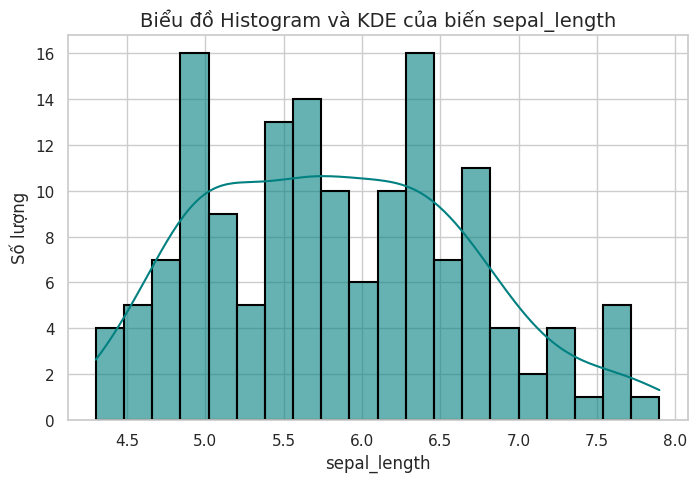

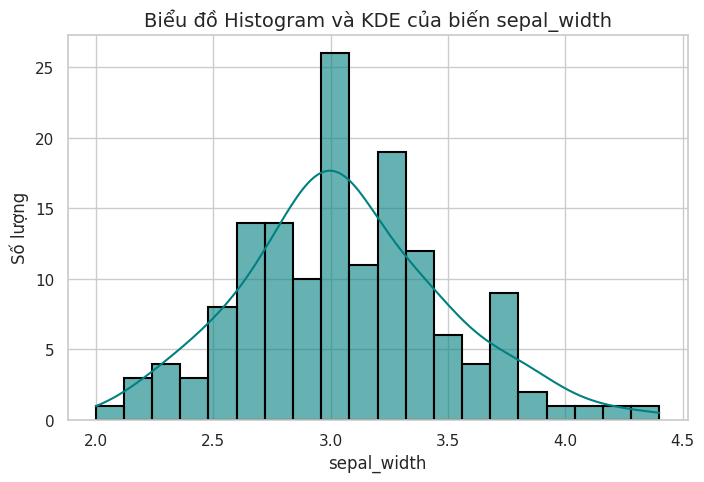

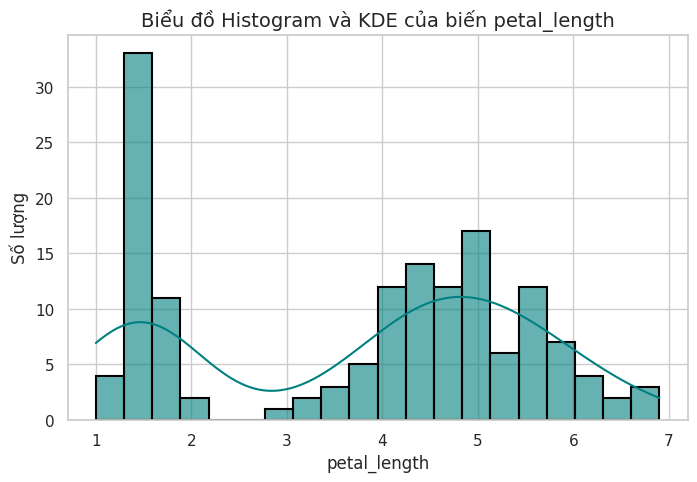

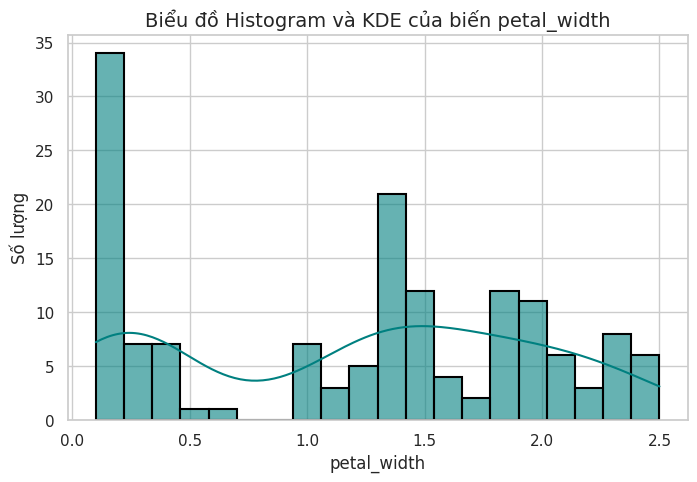

In [93]:
sns.set_theme(style = 'whitegrid')
for col in numeric_cols:
    plt.figure(figsize = (8, 5))
    
    sns.histplot(data = df, 
                 x = col, 
                 kde = True, 
                 color = 'teal', 
                 bins = 20,
                 edgecolor="black",
                 linewidth=1.5,
                 alpha=0.6,
                )
    plt.title(f"Biểu đồ Histogram và KDE của biến {col}", fontsize = 14)
    plt.xlabel(col, fontsize = 12)
    plt.ylabel("Số lượng", fontsize = 12)

    plt.show()

<span style="font-size: 120%;">2. Vẽ **boxplot** từng biến theo nhóm (*species*) để so sánh phân phối giữa các loài.

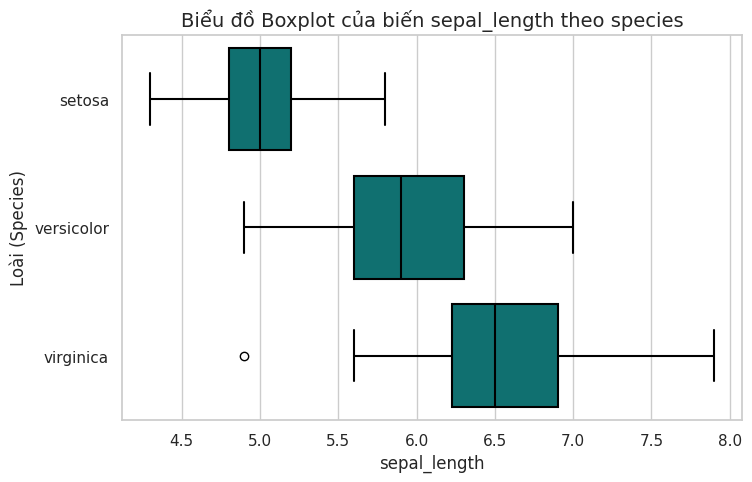

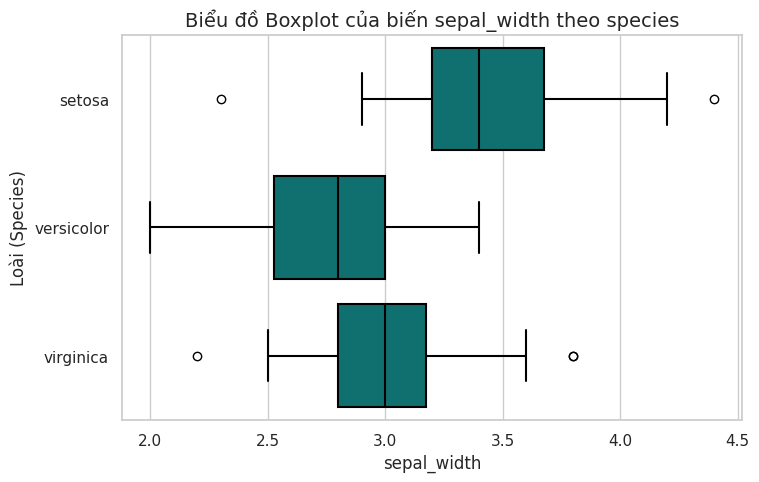

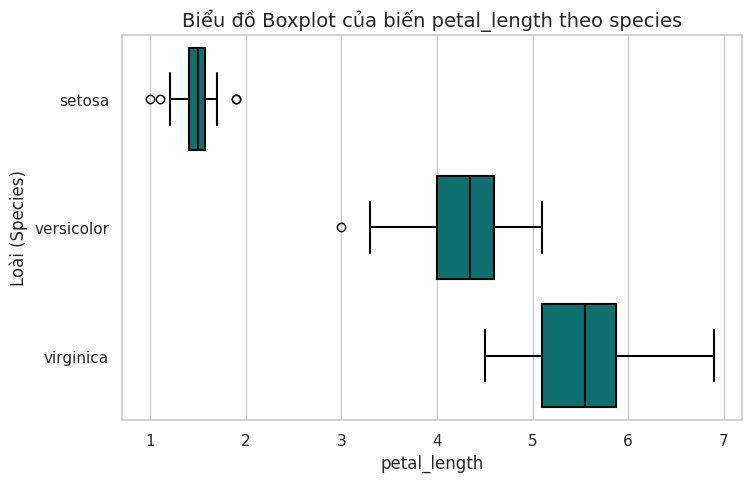

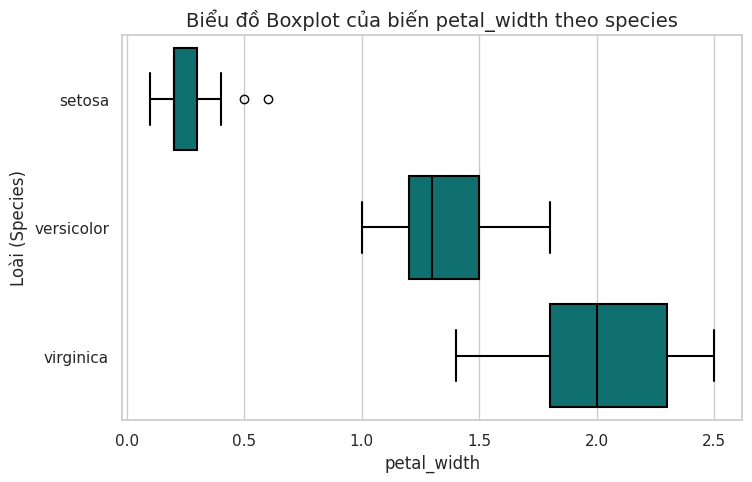

In [94]:
sns.set_theme(style = 'whitegrid')
for col in numeric_cols:
    plt.figure(figsize = (8, 5))
    
    sns.boxplot(data = df, 
                 x = col, 
                 y = "species",
                 color = "teal", 
                 linewidth=1.5,
                 linecolor="black"
                )
    plt.title(f"Biểu đồ Boxplot của biến {col} theo species", fontsize = 14)
    plt.xlabel(col, fontsize = 12)
    plt.ylabel("Loài (Species)", fontsize = 12)

    plt.show()

<span style="font-size: 120%;"> 3. **Mô phỏng:** Chọn một biến, sinh mẫu từ phân phối **Normal** có cùng mean và std bằng `np.random.normal`; vẽ chồng histogram dữ liệu thực tế với đường **PDF lý thuyết**.
* <span style="font-size: 110%;">Nhìn vào đồ thị bên dưới, dễ thấy **dữ liệu thực tế không hề khớp với đường PDF lý thuyết**.


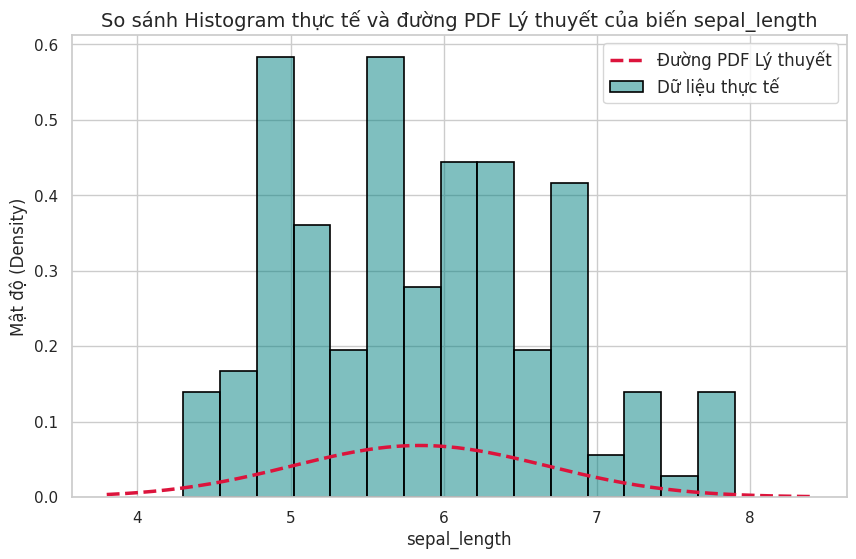

In [95]:
chosen_col = "sepal_length"
data_real = df[chosen_col]

mean_real = data_real.mean()
std_real = data_real.std()

np.random.seed(42)
data_simulated = np.random.normal(loc=mean_real, scale = std_real, size = len(data_real))

sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (10, 6))

# Vẽ Histogram thực tế
sns.histplot(data = data_real,
             stat = 'density',
             color = 'teal',
             alpha = 0.5,
             bins = 15,
             edgecolor = 'black',
             linewidth = 1.2,
             label = 'Dữ liệu thực tế',
            )

#Vẽ đường PDF Lý thuyết
x_axis = np.linspace(data_real.min() - 0.5, data_real.max() + 0.5, 200) #Tạo trục hoành
pdf_theoretical = (1/(mean_real * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - mean_real)/std_real)**2)

plt.plot(
    x_axis,
    pdf_theoretical,
    color = "crimson",
    linestyle = "--",
    linewidth = 2.5,
    label = "Đường PDF Lý thuyết"
)

plt.title(f"So sánh Histogram thực tế và đường PDF Lý thuyết của biến {chosen_col}", fontsize = 14)
plt.xlabel(chosen_col, fontsize = 12)
plt.ylabel("Mật độ (Density)", fontsize = 12)
plt.legend(fontsize = 12)

plt.show()

## Phần 3 — Phân tích đa biến & tương quan
<span style="font-size: 120%;">1. Tính **ma trận hiệp phương sai (covariance)** và **tương quan (correlation)** giữa các biến số.

In [96]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

covariance_matrix = df[numerical_cols].cov()
correlation_matrix = df[numerical_cols].corr()

print("Ma trận hiệp phương sai (Covariance)\n")
display(covariance_matrix.round(2))

print("Ma trận tương quan (Correlation)")
display(correlation_matrix.round(2))


Ma trận hiệp phương sai (Covariance)



,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.69,-0.04,1.27,0.52
sepal_width,-0.04,0.19,-0.33,-0.12
petal_length,1.27,-0.33,3.12,1.30
petal_width,0.52,-0.12,1.30,0.58


Ma trận tương quan (Correlation)


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


<span style="font-size: 120%;">2. Vẽ **heatmap** tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu <span style="color: blue;"><b>**đa cộng tuyến**</b></span> không?


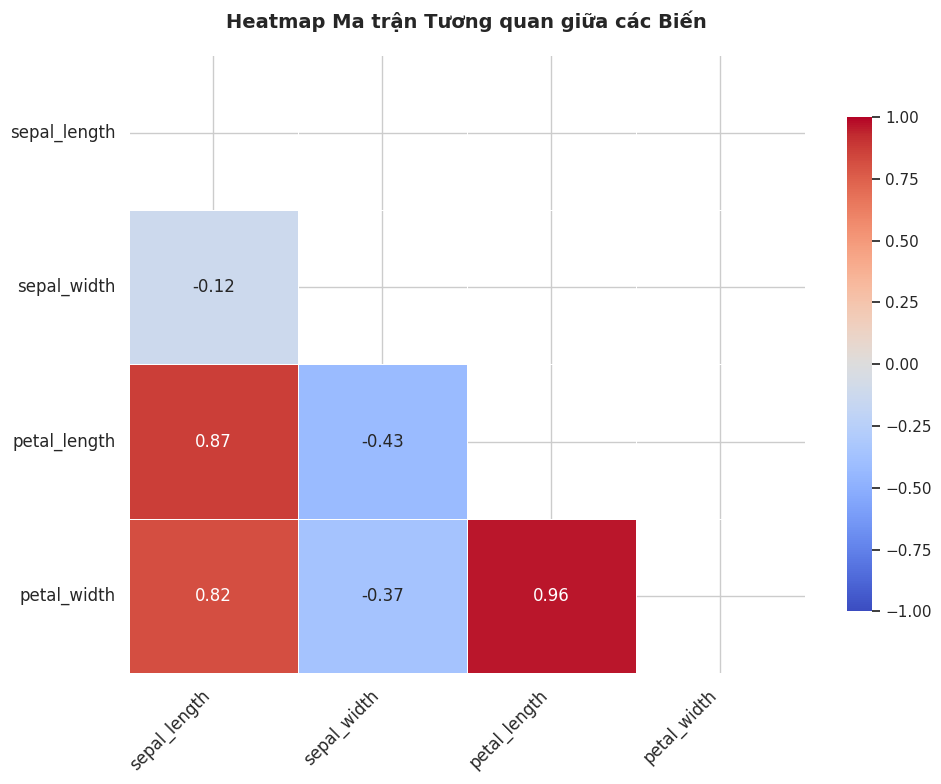

In [97]:
plt.figure(figsize = (10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Heatmap Ma trận Tương quan giữa các Biến", fontsize=14, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize = 12)
plt.yticks(rotation=0, fontsize = 12)
plt.tight_layout()
plt.show()

<span style="font-size: 120%;">3. Vẽ **pairplot** (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

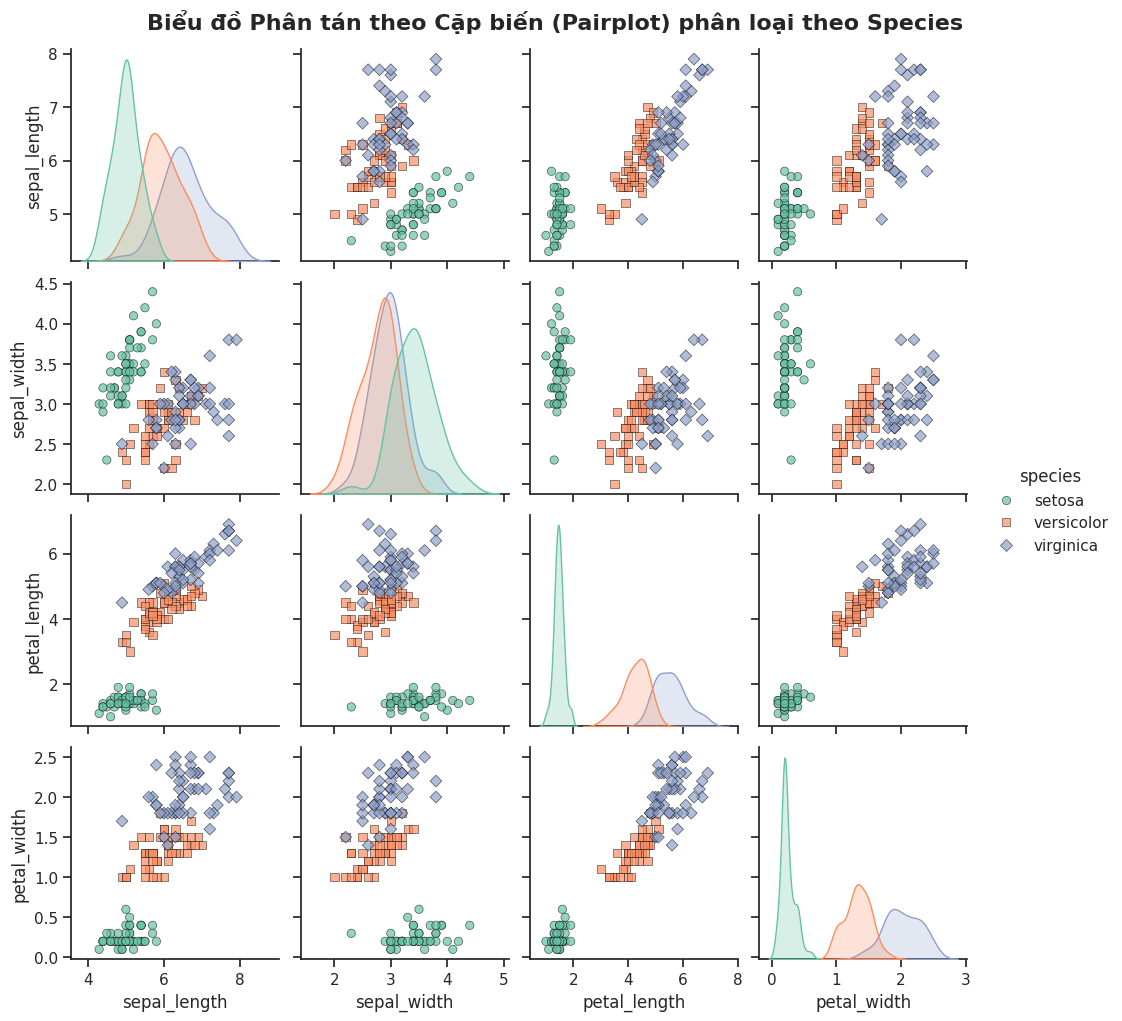

In [98]:
target_col = "species"

sns.set_theme(style="ticks")

g = sns.pairplot(
    df,
    hue=target_col,
    palette="Set2", 
    markers=["o", "s", "D"][: df[target_col].nunique()], 
    diag_kind="kde",  
    plot_kws={"alpha": 0.7, "edgecolor": "k", "linewidth": 0.5},  
)

g.fig.suptitle(
    "Biểu đồ Phân tán theo Cặp biến (Pairplot) phân loại theo Species",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.show()

### Phần 4 — Xác suất & Định lý Bayes
<span style="font-size: 110%;">**Bài toán chẩn đoán:** Một bệnh có tỉ lệ mắc trong dân số là *P*(*B*) = 0.01. Một xét
nghiệm có:
* <span style="font-size: 105%;">Độ nhạy (true positive): *P*(+|*B*) = 0.99.
* <span style="font-size: 105%;">Dương tính giả (false positive): *P*(+|¬*B*) = 0.05.

<span style="font-size: 120%;">1. Viết code tính xác suất hậu nghiệm *P*(*B*|+) bằng **định lý Bayes** và in kết quả.

In [99]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * (1 - P_B )
P_B_given_pos = P_pos_given_B * P_B / P_pos
print(f"Xác suất hậu nghiệm P(B | +) = {P_B_given_pos:.4f} ({P_B_given_pos * 100:.2f}%)")

Xác suất hậu nghiệm P(B | +) = 0.1667 (16.67%)


<span style="font-size: 120%;">2. **Khảo sát:** vẽ đồ thị *P*(*B* | +) khi tỉ lệ mắc bệnh *P*(*B*) thay đổi từ 0.001 đến 0.2.
Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".
* <span style="font-size: 110%;">Hiện tượng này xảy ra vì bệnh *quá hiếm gặp* (chỉ 1%), khiến số người khỏe mạnh bị kết luận nhầm (495 người dương tính giả) lớn *gấp 5 lần* số người thực sự mắc bệnh được phát hiện (99 người dương tính thật).

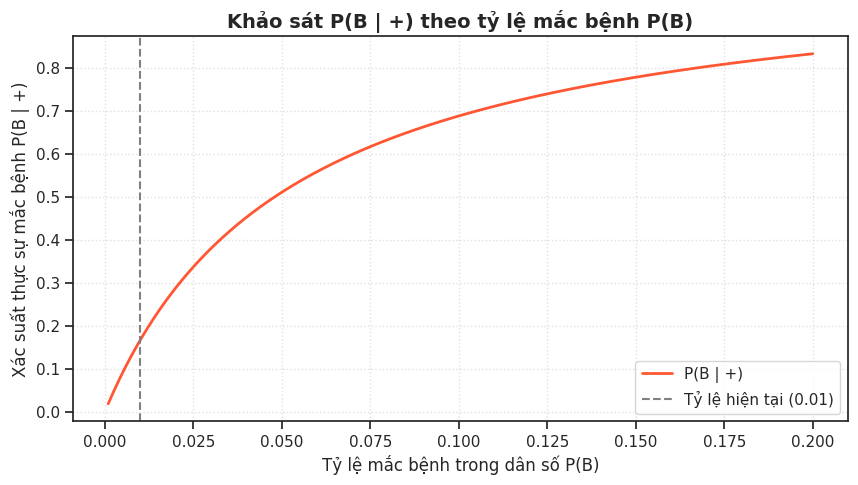

In [100]:
P_B_range = np.linspace(0.001, 0.2, 500)

P_B_given_pos_range = (P_pos_given_B * P_B_range) / (
    (P_pos_given_B * P_B_range) + (P_pos_given_not_B * (1 - P_B_range))
)

# Tiến hành vẽ đồ thị
plt.figure(figsize=(10, 5))
plt.plot(P_B_range, P_B_given_pos_range, label="P(B | +)", color="#FF5733", linewidth=2)
plt.title("Khảo sát P(B | +) theo tỷ lệ mắc bệnh P(B)", fontsize=14, fontweight='bold')
plt.xlabel("Tỷ lệ mắc bệnh trong dân số P(B)", fontsize=12)
plt.ylabel("Xác suất thực sự mắc bệnh P(B | +)", fontsize=12)
plt.axvline(x=0.01, color='gray', linestyle='--', label='Tỷ lệ hiện tại (0.01)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

<span style="font-size: 120%;">3. <span style="color: orange;"><b>*(Tùy chọn, bonus)*</b></span> Xây dựng một bộ lọc spam đơn giản theo **Naive Bayes** trên vài
từ khóa cho sẵn; tính *P*(spam | email) cho 2–3 email ví dụ.

In [105]:
training_data = [
    (['khuyến_mãi', 'trúng_thưởng', 'quà'], True),
    (['nhận', 'quà', 'trúng_thưởng', 'lớn'], True),
    (['khuyến_mãi', 'đặc_biệt', 'ngay'], True),
    (['lịch', 'họp', 'dự_án', 'với', 'đối_tác'], False),
    (['báo_cáo', 'tiến_độ', 'dự_án', 'họp'], False),
]

total_emails = len(training_data)
spam_emails = sum(1 for _, is_spam in training_data if is_spam)
ham_emails = total_emails - spam_emails

P_spam = spam_emails / total_emails
P_ham = ham_emails / total_emails

vocab = ['khuyến_mãi', 'trúng_thưởng', 'họp', 'dự_án']
spam_words_count = {word: 1 for word in vocab}  
ham_words_count = {word: 1 for word in vocab}

total_spam_words = len(vocab)
total_ham_words = len(vocab)

for words, is_spam in training_data:
    for word in words:
        if word in vocab:
            if is_spam:
                spam_words_count[word] += 1
                total_spam_words += 1
            else:
                ham_words_count[word] += 1
                total_ham_words += 1

def predict_spam(email_content):
    log_prob_spam = math.log(P_spam)
    log_prob_ham = math.log(P_ham)
    
    for word in email_content:
        if word in vocab:
            log_prob_spam += math.log(spam_words_count[word] / total_spam_words)
            log_prob_ham += math.log(ham_words_count[word] / total_ham_words)
            
    max_log = max(log_prob_spam, log_prob_ham)
    prob_spam_raw = math.exp(log_prob_spam - max_log)
    prob_ham_raw = math.exp(log_prob_ham - max_log)
    
    P_spam_given_email = prob_spam_raw / (prob_spam_raw + prob_ham_raw)
    return P_spam_given_email

test_emails = [
    ['khuyến_mãi', 'nhận', 'trúng_thưởng'],
    ['lịch', 'họp', 'thảo_luận', 'dự_án'],   
    ['khuyến_mãi', 'họp', 'dự_án']           
]
for i, email in enumerate(test_emails, 1):
    prob = predict_spam(email)
    classification = "SPAM" if prob > 0.5 else "HỢP LỆ"
    print(f"Email {i} {email} -> Xác suất là Spam: {prob:.2f} | Phân loại: {classification}")


Email 1 ['khuyến_mãi', 'nhận', 'trúng_thưởng'] -> Xác suất là Spam: 0.93 | Phân loại: SPAM
Email 2 ['lịch', 'họp', 'thảo_luận', 'dự_án'] -> Xác suất là Spam: 0.14 | Phân loại: HỢP LỆ
Email 3 ['khuyến_mãi', 'họp', 'dự_án'] -> Xác suất là Spam: 0.33 | Phân loại: HỢP LỆ
